Najpierw importuję biblioteki, wyznaczam ścieżkę i odczytuję plik z danymi

In [252]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [253]:
from google.colab import drive
drive.mount('/content/drive')
data_path = '/content/drive/MyDrive/titanic.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [254]:
titanic = pd.read_csv(data_path)
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Sprawdzam podstawowe informacje o zbiorze takie jak kształt i typy danych

In [255]:
titanic = titanic.convert_dtypes()
titanic.dtypes

,0
PassengerId,Int64
Survived,Int64
Pclass,Int64
Name,string[python]
Sex,string[python]
Age,Float64
SibSp,Int64
Parch,Int64
Ticket,string[python]
Fare,Float64


In [256]:
print("Kształt zbioru:", titanic.shape)
print("\nTypy danych i braki:\n")
titanic.info()

Kształt zbioru: (891, 12)

Typy danych i braki:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    Int64  
 1   Survived     891 non-null    Int64  
 2   Pclass       891 non-null    Int64  
 3   Name         891 non-null    string 
 4   Sex          891 non-null    string 
 5   Age          714 non-null    Float64
 6   SibSp        891 non-null    Int64  
 7   Parch        891 non-null    Int64  
 8   Ticket       891 non-null    string 
 9   Fare         793 non-null    Float64
 10  Cabin        204 non-null    string 
 11  Embarked     889 non-null    string 
dtypes: Float64(2), Int64(5), string(5)
memory usage: 89.8 KB


Jak widać kolumna Cabin ma bardzo wiele braków. Niestety, w związku z tym zastanawiam się o jej usunięciu, jednak zanim to zrobię warto jeszcze sprawdzić czy Cabin ma jakąś korelację z klasą pokładową:

In [257]:
titanic['Cabin'].str[0].unique()

<StringArray>
[<NA>, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T']
Length: 9, dtype: string

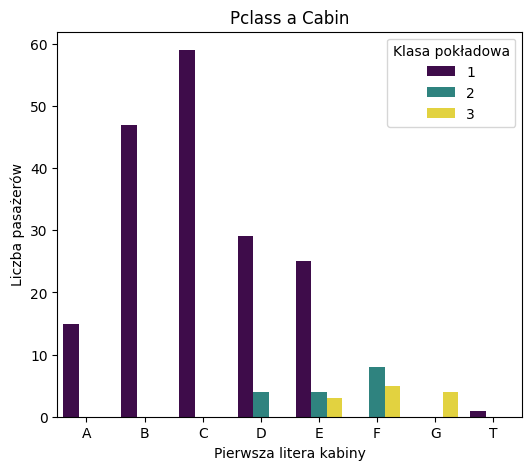

In [258]:
plt.figure(figsize=(6, 5))
sns.countplot(
    x=titanic["Cabin"].str[0],
    hue=titanic["Pclass"],
    palette="viridis",
    order=["A", "B", "C", "D", "E", "F", "G", "T"],
)
plt.title("Pclass a Cabin")
plt.xlabel("Pierwsza litera kabiny")
plt.ylabel("Liczba pasażerów")
plt.legend(title="Klasa pokładowa")
plt.show()

Jak widać na podstawie posiadanych danych kabiny A, B i C są okupowane wyłącznie przez osoby z klasy pierwszej. Natomiast ciężko cokolwiek powiedzieć o kabinach D-T. W ten sposób nie da się uzupełnić danych o kabinach.

Usuwam kolumny Ticket oraz Cabin, bo Ticket to unikalny ciąg znaków, więc nie będzie potrzebny do analizy, a Cabin posiada zbyt dużo brakujących wartości, by wiarygodnie tą kolumnę dać do analizy.

In [259]:
titanic = titanic.drop(columns=["Ticket", "Cabin"]).copy()
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.25,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.925,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.05,S


Przy okazji od razu dodamy nowe dwie komórki.

Title to będzie tytuł wyciągnięty z imienia i nazwiska, który pozwala wychwycić pozycję społeczną oraz wiek.

FamilySize, czyli suma SibSp + Parch + sam pasażer. Pasażerowie podróżujący samotnie lub w zbyt dużych rodzinach mogliby mieć inne szanse na przeżycie.

Dzięki czemu można się pozbyć od razu komórki Name, która sama w sobie też za wiele nie wniesie do analizy, ponieważ każdy się nazywał inaczej.

In [260]:
# nowa funkcja do grupania tytułów na rzadkie, miss, mr i mrs
def extract_title(name):
    title = name.split(",")[1].split(".")[0].strip()
    rare_titles = [
        "Lady",
        "Countess",
        "the Countess",
        "Capt",
        "Col",
        "Don",
        "Dr",
        "Major",
        "Rev",
        "Sir",
        "Jonkheer",
        "Dona",
    ]
    if title in rare_titles:
        return "Rare"
    elif title in ["Mlle", "Ms"]:
        return "Miss"
    elif title == "Mme":
        return "Mrs"
    return title


# tworzenie kolumn i usunięcie kolumny Name
titanic["Title"] = titanic["Name"].apply(extract_title)
titanic["FamilySize"] = titanic["SibSp"] + titanic["Parch"] + 1
titanic[["Title", "FamilySize"]].head()

,Title,FamilySize
0,Mr,2
1,Mrs,2
2,Miss,1
3,Mrs,2
4,Mr,1


In [261]:
titanic['Title'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Rare'], dtype=object)

In [262]:
titanic = titanic.drop(columns=["Name"])

Teraz chcę sprawdzić czy są jakieś nieścisłości w danych poprzez wypisanie poszczególnych unikalnych wartości danych kolumn

In [263]:
titanic['Survived'].unique()

<IntegerArray>
[0, 1]
Length: 2, dtype: Int64

In [264]:
titanic['Pclass'].unique()

<IntegerArray>
[3, 1, 2]
Length: 3, dtype: Int64

In [265]:
titanic['Sex'].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: string

In [266]:
titanic['Age'].unique()

<FloatingArray>
[22.0, 38.0, 26.0, 35.0, <NA>, 54.0,  2.0, 27.0, 14.0,  4.0, 58.0, 20.0, 39.0,
 55.0, 31.0, 34.0, 15.0, 28.0,  8.0, 19.0, 40.0, 66.0, 42.0, 21.0, 18.0,  3.0,
  7.0, 49.0, 29.0, 65.0, 28.5,  5.0, 11.0, 45.0, 17.0, 32.0, 16.0, 25.0, 0.83,
 30.0, 33.0, 23.0, 24.0, 46.0, 59.0, 71.0, 37.0, 47.0, 14.5, 70.5, 32.5, 12.0,
  9.0, 36.5, 51.0, 55.5, 40.5, 44.0,  1.0, 61.0, 56.0, 50.0, 36.0, 45.5, 20.5,
 62.0, 41.0, 52.0, 63.0, 23.5, 0.92, 43.0, 60.0, 10.0, 64.0, 13.0, 48.0, 0.75,
 53.0, 57.0, 80.0, 70.0, 24.5,  6.0, 0.67, 30.5, 0.42, 34.5, 74.0]
Length: 89, dtype: Float64

In [267]:
titanic['SibSp'].unique()

<IntegerArray>
[1, 0, 3, 4, 2, 5, 8]
Length: 7, dtype: Int64

In [268]:
titanic['Parch'].unique()

<IntegerArray>
[0, 1, 2, 5, 3, 4, 6]
Length: 7, dtype: Int64

In [269]:
titanic['Embarked'].unique()

<StringArray>
['S', 'C', 'Q', <NA>]
Length: 4, dtype: string

Jak widać jedyną nieścisłością jest value 'nan' w Embarked, więc zajmę się usunięciem wszelkich braków, które mogą być w kolumnach.

In [270]:
print("Braki przed uzupełnieniem:")
print(titanic.isnull().sum()[titanic.isnull().sum() > 0])

Braki przed uzupełnieniem:
Age         177
Fare         98
Embarked      2
dtype: int64


In [271]:
# Uzupełnienie Embarked najczęstszą wartością
embarked_mode = titanic["Embarked"].mode()[0]
titanic["Embarked"] = titanic["Embarked"].fillna(embarked_mode)

# Uzupełnienie Fare medianą
fare_median = titanic["Fare"].median()
titanic["Fare"] = titanic["Fare"].fillna(fare_median)

# Uzupełnienie Age medianą w grupach wyznaczonych przez Title i Pclass
titanic["Age"] = titanic.groupby(["Title", "Pclass"])["Age"].transform(
    lambda x: x.fillna(x.median())
)

print("\nBraki po imputacji:")
print(titanic.isnull().sum().sum())


Braki po imputacji:
0


Teraz jak już jest wszystko ok, to można zwizualizować. Zrobię funkcję, która zrobi rozkład i outlier dla podanej kolumny oraz jej użyję dla kolumn Age, Fare i FamilySize.

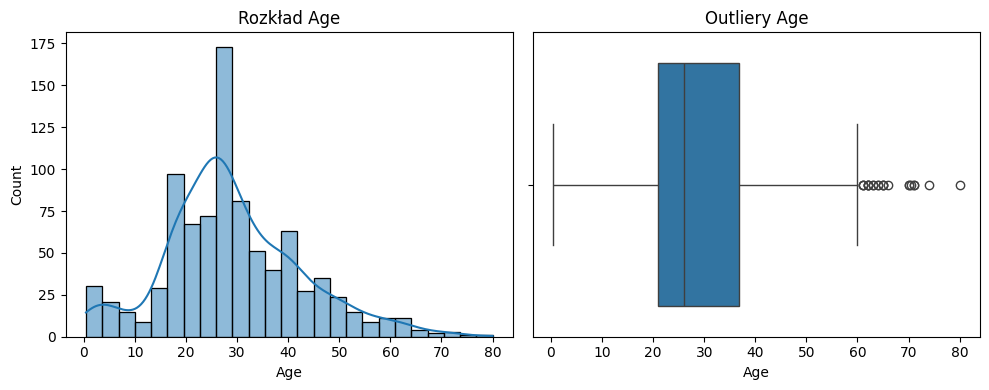

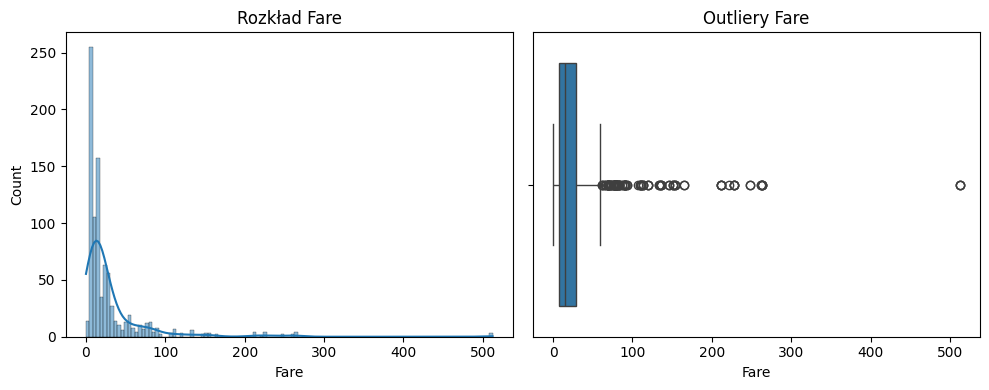

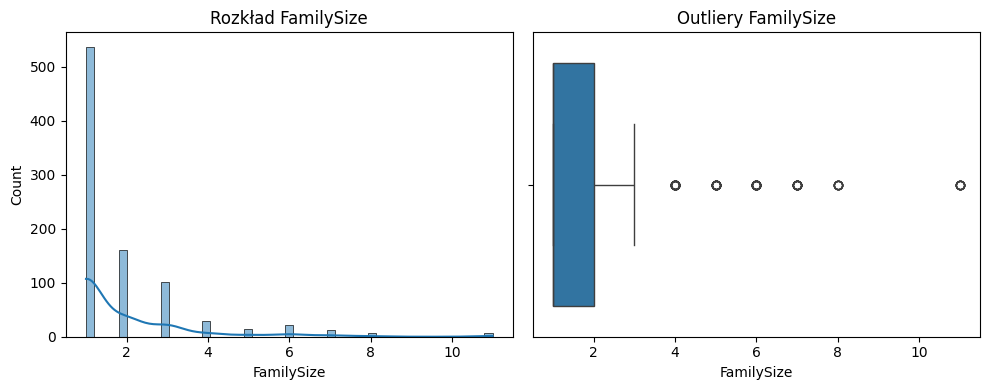

In [272]:
def plot_distribution_and_outliers(data, column):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.histplot(data[column], kde=True, ax=axes[0])
    axes[0].set_title(f"Rozkład {column}")
    sns.boxplot(x=data[column], ax=axes[1])
    axes[1].set_title(f"Outliery {column}")
    plt.tight_layout()
    plt.show()

for col in ["Age", "Fare", "FamilySize"]:
    plot_distribution_and_outliers(titanic, col)

Pasażerami statku byli głównie dojrzali ludzie, nie płynący z dużą kompanią. Bilety w większości nie były drogie, jednak widać pewne odchylenia.

Sprawdzę przeżywalność względem płci, klasy, portu i tytułu.

In [273]:
def survivability(col):
  plt.figure(figsize=(6, 4))
  sns.countplot(data=titanic, x=col, hue="Survived", palette="viridis")
  plt.title(f"Przeżywalność względem {col}")
  plt.xlabel(col)
  plt.ylabel("Liczba pasażerów")
  plt.legend(title="Przeżyli", labels=["Nie", "Tak"])
  plt.show()

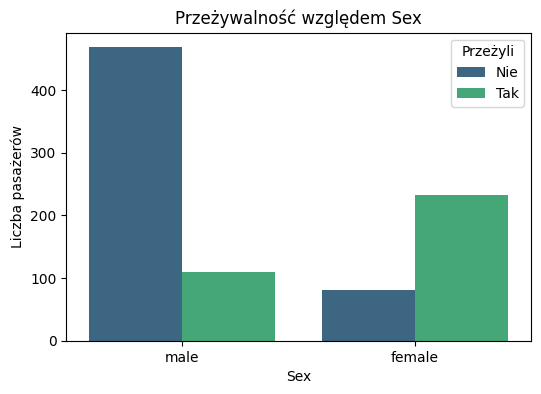

In [274]:
survivability("Sex")

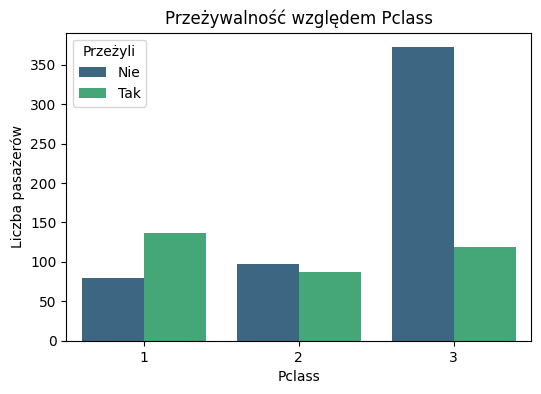

In [275]:
survivability("Pclass")

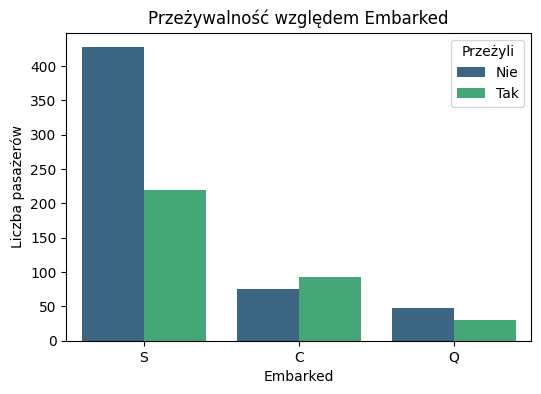

In [276]:
survivability("Embarked")

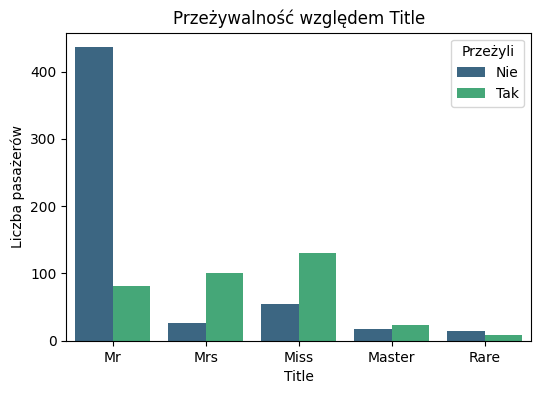

In [277]:
survivability("Title")

(1, 1000)

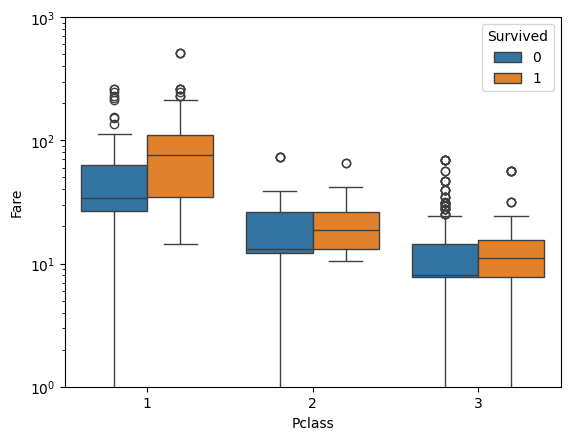

In [278]:
sns.boxplot(data=titanic, y='Fare', x='Pclass', hue='Survived')
plt.yscale('log')
plt.ylim(1, 1000)

Widać wyraźną korelację między ceną biletów a klasą społeczną. Osoby z klasy pierwszej, które kupiły droższe bilety miały nieco większe szanse na przeżycie.

Jak widać poniżej, umarła ponad połowa pasażerów

In [279]:
titanic.Survived.value_counts(normalize=True)

,proportion
Survived,
0,0.616162
1,0.383838


Chcę sprawdzić czy klasa i cena biletu mają związek na przeżywalność

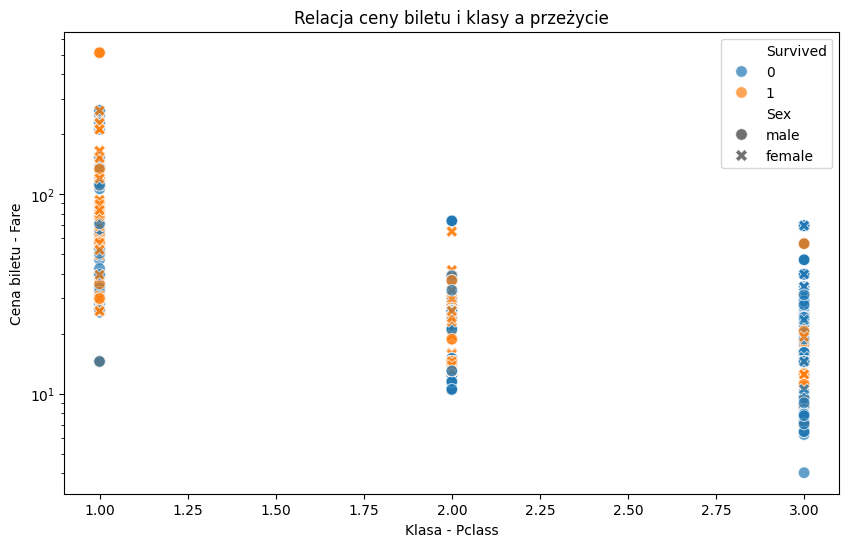

In [280]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=titanic.assign(Pclass=titanic["Pclass"].astype(int)),
    x="Pclass",
    y="Fare",
    hue="Survived",
    style="Sex",
    alpha=0.7,
    s=70,
)
plt.yscale("log")
plt.title("Relacja ceny biletu i klasy a przeżycie")
plt.xlabel("Klasa - Pclass")
plt.ylabel("Cena biletu - Fare")
plt.show()

Jak widać na wykresie, to osoby z pierwszej klasy miały większą szansę na przeżycie niż osoby, które zakupiły bilet w klasie trzeciej. Jednocześnie widać również różnicę w cenach, chociaż niektóre się wspólnie pokrywają ze sobą.

Teraz chciałabym stworzyć Heatmapę ukazujące zależności pomiędzy poszczególnymi klasami. Chciałabym w takim wypadku zamienić kolumnę płci na numeryczną, aby móc ją również pokazać na wykresie, ponieważ myślę, że będzie miała ona duży wpływ na przeżywalność.

In [281]:
titanic["Sex"] = titanic["Sex"].map({"male": 0, "female": 1})
titanic.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize
0,1,0,3,0,22.0,1,0,7.25,S,Mr,2
1,2,1,1,1,38.0,1,0,71.2833,C,Mrs,2
2,3,1,3,1,26.0,0,0,7.925,S,Miss,1
3,4,1,1,1,35.0,1,0,53.1,S,Mrs,2
4,5,0,3,0,35.0,0,0,8.05,S,Mr,1


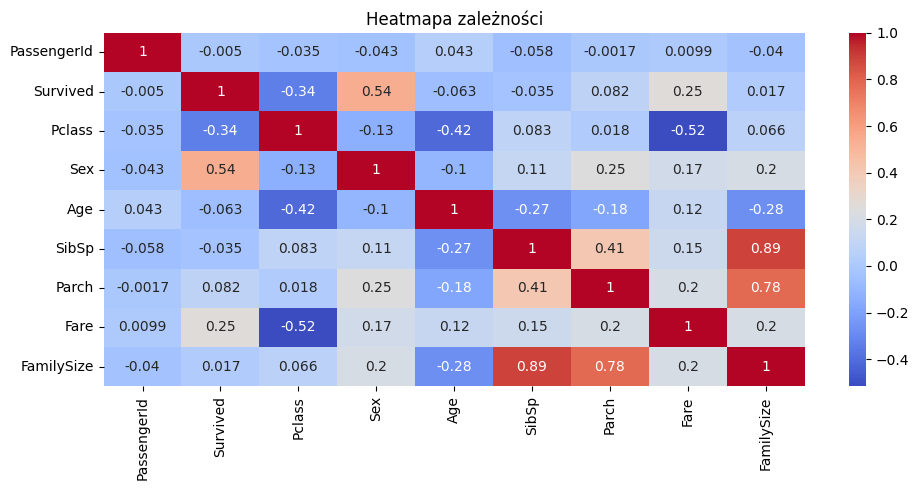

In [282]:
corr_matrix = titanic.corr(numeric_only=True)

plt.figure(figsize=(10, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Heatmapa zależności")
plt.tight_layout()
plt.show()

Powyższa Heatmapa przedstawia liniowe zależności pomiędzy zmiennymi numerycznymi w zbiorze danych.

Na przykład, co ciekawe, cena biletu wykazuje dodatnią korelację z przeżyciem, co oznacza, że pasażerowie z droższymi biletami mieli wyższe szanse na ratunek. Tak samo z klasą Pclass. Jako, że jej połączenie z Survived jest ujemne, oznacza to, że im wyższy numer klasy tym niższe szanse były na przeżycie. Kobiety również miały silną przewagę.

Z rzeczy niezwiązanych z przeżywalnością, to np. pierwsza klasa wiąże się z gwałtownym wzrostem ceny biletu, osoby podróżujące z rodzeństwem lub małżonkiem często podróżowały również z dziećmi/rodzicami, co potwierdza zasadność stworzenia kolumny FamilySize.

Na sam koniec zamierzam zamienić wszystkie wartości na numeryczne, ponieważ z tego co się dowiedziałam, to niektórych operacji nie da się wykonać na zmiennych nienumerycznych.

Powód dla którego usuwam Embarked_C jest taki, że podczas analizy jeśli pasażer będzie miał w Embarked_Q i Embarked_S wartości 0, to będzie to równoznaczne z wypłynięciem z portu C. To samo się tyczy tytułu.

In [283]:
titanic_final = pd.get_dummies(
    titanic, columns=["Embarked", "Title"], drop_first=True, dtype=int
)
print("Kształt końcowej macierzy:", titanic_final.shape)
titanic_final.head()

Kształt końcowej macierzy: (891, 15)


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,0,3,0,22.0,1,0,7.25,2,0,1,0,1,0,0
1,2,1,1,1,38.0,1,0,71.2833,2,0,0,0,0,1,0
2,3,1,3,1,26.0,0,0,7.925,1,0,1,1,0,0,0
3,4,1,1,1,35.0,1,0,53.1,2,0,1,0,0,1,0
4,5,0,3,0,35.0,0,0,8.05,1,0,1,0,1,0,0


Sprawdzam czy występują jakiekolwiek braki danych :)

In [284]:
assert titanic_final.isnull().sum().sum() == 0, "Są braki danych"
print("Zbiór jest w pełni oczyszczony i gotowy do modelowania.")

Zbiór jest w pełni oczyszczony i gotowy do modelowania.
